In [9]:
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from matplotlib import pyplot as plt
from mlxtend.plotting import plot_decision_regions
import numpy as np
import pandas as pd

In [10]:
df = pd.read_csv("C://Users//Acer//OneDrive//Desktop//Datasets//3_class_classifiaction.csv")
x = np.array(df.drop(columns=['target']))
y = np.array(df['target'])
x_train,x_test,y_train,y_test = (train_test_split(x,y,test_size=0.2,random_state=42))

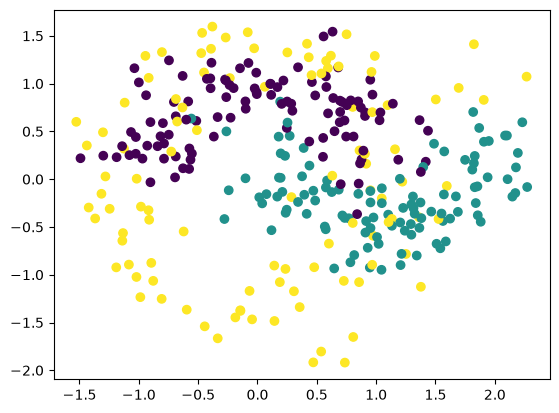

In [11]:
plt.scatter(x_train[:,0],x_train[:,1],c=y_train)

In [12]:
bc = BaggingClassifier(n_estimators=50,random_state=42)
rf = RandomForestClassifier(n_estimators=50,random_state=42)
dt = DecisionTreeClassifier(random_state=42)

classifiers = [('bc',bc),('rf',rf),('dt',dt)]

The cv score for bc is 0.7591442374051071
The accuracy on test set is 0.75
The cv score for rf is 0.7498274672187716
The accuracy on test set is 0.7625
The cv score for dt is 0.6905452035886819
The accuracy on test set is 0.675


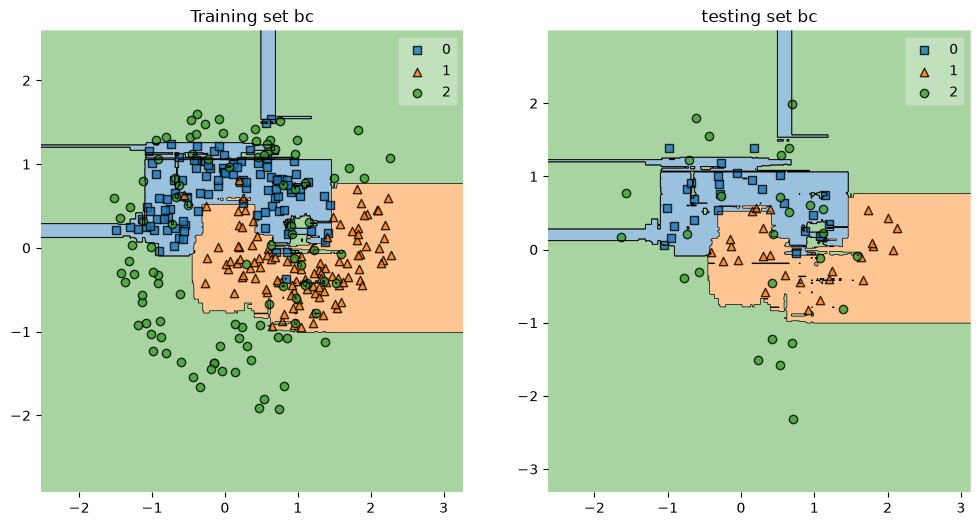

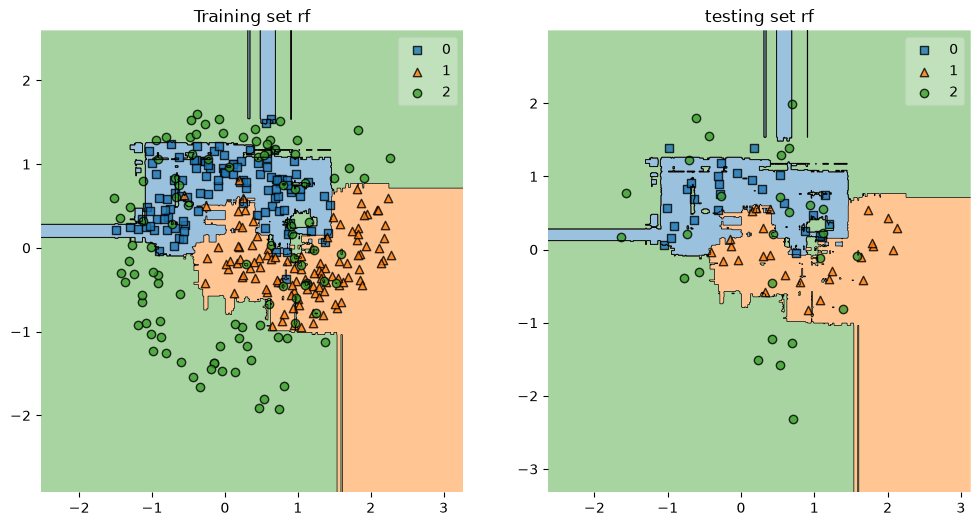

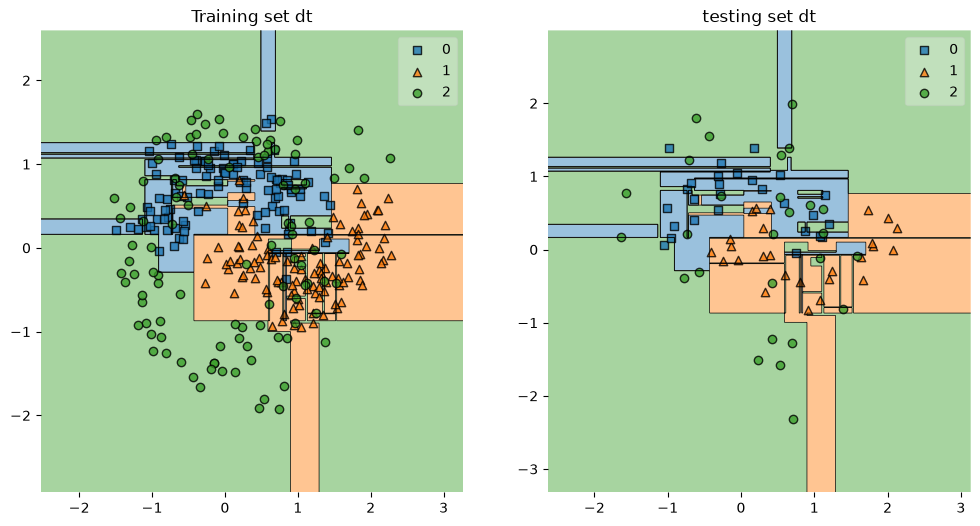

In [13]:
for clf in classifiers:
    clf[1].fit(x_train,y_train)
    cv = cross_val_score(clf[1],x_train,y_train,cv=7,scoring='accuracy')
    print(f"The cv score for {clf[0]} is {np.mean(cv)}")
    y_pred = clf[1].predict(x_test)
    print(f"The accuracy on test set is {accuracy_score(y_test,y_pred)}")
    plt.figure(figsize=(12,6))
    plt.subplot(121)
    plot_decision_regions(x_train,y_train,clf[1])
    plt.title(f"Training set {clf[0]}")
    plt.subplot(122)
    plot_decision_regions(x_test,y_test,clf[1])
    plt.title(f"testing set {clf[0]}")

In [14]:
rfc = RandomForestClassifier(random_state=42)
param_grid1 = {
    'n_estimators' : [50,100,200,300],
    'criterion' : ['gini','entropy','log_loss'],
    'max_depth' : [None,5,10,20],
    'max_features' : ['sqrt', 'log2'],
    'max_samples' : [None,0.25,0.3,0.4,0.5,0.75]
}
grid1 = GridSearchCV(estimator=rfc,param_grid=param_grid1,scoring='accuracy',cv=7,n_jobs=-1,error_score='raise')
grid1.fit(x_train,y_train)
print(f"Best parameters : {grid1.best_params_}")
print(f"Best cv score : {grid1.best_score_}")

Best parameters : {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_samples': 0.5, 'n_estimators': 50}
Best cv score : 0.7843340234644582


In [15]:
bagC = BaggingClassifier(estimator=None,random_state=42)
param_grid2 = {
    'n_estimators' : [50,100,200,300],
    'max_features' : [1.0,0.5],
    'max_samples' : [1.0,0.25,0.3,0.4,0.5,0.75],
    'bootstrap' : [True,False],
    'bootstrap_features' : [True,False]
}
grid2 = GridSearchCV(estimator=bagC,param_grid=param_grid2,scoring='accuracy',cv=7,n_jobs=-1,error_score='raise')
grid2.fit(x_train,y_train)
print(f"Best parameters : {grid2.best_params_}")
print(f"Best cv score : {grid2.best_score_}")

Best parameters : {'bootstrap': True, 'bootstrap_features': False, 'max_features': 1.0, 'max_samples': 0.3, 'n_estimators': 50}
Best cv score : 0.7877156659765355
